In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
import numpy as np

This notebook focuses on Steps 1 and 2 of *Compare AI Exposure to AI Usage* and *Identify different AI transition archetypes* found in the [Concept Note](https://docs.google.com/document/d/1L5J0yp9uWzy_J4mkM9Ga62QGa-aa6oiG5bPMD9hmYCE/edit?usp=sharing) provided by Ms. Angela.

The granularity of the data is per SOC Occupation (where there 1,016 SOC occupations). However, due to privacy reasons (and also because apparently occupations related to military just really don't have data???), not all occupations have values (specifically on data which came from Anthropic.) They are held as null values.

# Step 1  - Compare AI Exposure to AI Usage

## a) Showing the Benefit of C-AIOE over AIOE as a way to measure Theoretical AI Exposure

### Definition of the Data and Metrics
Before comparing the metrics, we first define what each measure represents and what we expect to observe in the correlation matrix.

1. `AIOE` is the AI Occupational Exposure index from the World Bank. Its values range from approximately 5 to 7 in our dataset. Since AIOE is an index, the absolute value is less important than the relative exposure of occupations to one another.

2. `Complementarity` measures the extent to which AI is expected to complement or augment human work rather than automate it. The metric ranges from 0% to 100%, with higher values indicating greater potential for augmentation.

3. `C-AIOE` is our complementarity-adjusted AIOE measure. We interpret this as a theoretical measure of a job's potential risk of being automated or replaced by AI. Since C-AIOE incorporates both AI exposure and complementarity, we expect it to increase as AIOE increases and decrease as complementarity increases.

4. `Observed Exposure` is based on Anthropic's observed Claude usage data and is defined as the share of a job being performed or accelerated by an LLM. Because Anthropic's methodology incorporates [automation into the calculation of Observed Exposure](https://cdn.sanity.io/files/4zrzovbb/website/e5f77fc0e77c0185110b5e4b909602791ae76eae.pdf), higher automation should correspond to higher observed exposure. We therefore interpret this as an observed measure of a job's potential AI automation risk.

### Motivation of Choosing C-AIOE over AIOE as the Main Metric to Compare Against Observed Exposure
The motivation for using C-AIOE rather than AIOE when comparing against Observed Exposure is that the two measures should be compared on a similar conceptual basis. AIOE captures AI exposure alone, whereas Observed Exposure incorporates both exposure to AI and the extent to which AI can automate the work. C-AIOE similarly combines AI exposure with complementarity to produce a single measure that accounts for both dimensions. In other words, Observed Exposure combines exposure and complementarity-related information into one observed measure, while C-AIOE combines exposure and complementarity into one theoretical measure. Comparing C-AIOE with Observed Exposure therefore provides a more conceptually comparable comparison than using AIOE alone.

### Granularity

Of the 1,016 SOC codes available for this analysis, 756 (74%) have complete data for AIOE, Complementarity, C-AIOE, and Observed Exposure. The correlation analysis and visualizations in this step therefore use these 756 occupations.

In [24]:
ai_metrics_df = pd.read_csv('../data/auxiliary/soc_consolidated_ai_metrics.csv')

columns_to_keep = [
    "O*NET-SOC Code",
    "Title",
    "AIOE",
    "Complementarity",
    "C-AIOE",
    "Observed Exposure",
    "Augmentation Percent",
    "Automation Percent",
    "Directive Percent",
    "Feedback Loop Percent",
    "Learning Percent",
    "Task Iteration Percent",
    "Validation Percent",
    "None Percent",
]
exposure_df = ai_metrics_df[columns_to_keep].dropna()

# get the data from Elondou
open_ai_df = pd.read_csv('../data/ai_measurements/occ_level.csv')
exposure_df = exposure_df.merge(open_ai_df, on='O*NET-SOC Code', how='left')

## b) Showing that there exists a big difference between AIOE and C-AIOE

### Definition of the Data and Metrics
TL;DR: For all columns, a higher value generally indicates greater AI exposure or risk, except for `Complementarity`, where a higher value indicates greater potential for AI to complement rather than substitute human work.

1. `nth Top AIOE (AIOE Rank)`

Indicates an occupation's ranking based on its AIOE value, where `1` represents the occupation with the highest AIOE. A lower rank therefore indicates greater AI exposure.

2. `nth Top C-AIOE (C-AIOE Rank)`

Follows the same ranking convention as `nth Top AIOE (AIOE Rank)`, but uses the complementarity-adjusted AIOE (C-AIOE). A lower rank indicates greater AI exposure after accounting for complementarity.

3. `Increase in Exposure (Rank Change)`

Represents the change in an occupation's rank between AIOE and C-AIOE. A positive value indicates that the occupation moved to a higher numerical rank, while a negative value indicates movement toward a lower numerical rank.

4. `Increase in Exposure (Rank Change) Percent`

Represents the percentage change in an occupation's ranking after adjusting AIOE for complementarity. Its interpretation follows the direction of `Rank Change`, with positive values indicating movement toward a higher numerical rank and negative values indicating movement toward a lower numerical rank.

### Main Insight
1. Although the median and mean rank changes are -10 and 0, the changes are still nontrivial to the standard deviation being 193. Hence, we should actually check what are the differences.
2. The differences can be seen by looking at the bottom and top 5 changes in rank. A positive change rank implies that a job became more exposed after accounting for complementarity and vice-versa. For a more general overview, we can also group by and take the averange change in rank for each occupation group. The biggest change were for Legal and Community & Social Development Occupations  where they became less by 3,928% and 1,481%.

In [25]:
exposure_df["nth Top AIOE (AIOE Rank)"] = (
    exposure_df["AIOE"]
    #.rank(ascending=False, method="min")
    .rank(pct=True)
)
#).astype(int)

exposure_df["nth Top C-AIOE (C-AIOE Rank)"] = (
    exposure_df["C-AIOE"]
    #.rank(ascending=False, method="min")
    .rank(pct=True)
)
#).astype(int)

exposure_df["Increase in Exposure (Rank Change)"] = (
    exposure_df["nth Top C-AIOE (C-AIOE Rank)"] - 
    exposure_df["nth Top AIOE (AIOE Rank)"]
)

exposure_df["Increase in Exposure (Rank Change) Percent"] = (exposure_df["Increase in Exposure (Rank Change)"] / exposure_df["nth Top AIOE (AIOE Rank)"]) * 100
exposure_df = exposure_df.sort_values(by='Increase in Exposure (Rank Change) Percent', ascending=False)

In [26]:
exposure_df['Increase in Exposure (Rank Change)'].describe()

count    5.370000e+02
mean     1.323171e-17
std      2.516456e-01
min     -7.653631e-01
25%     -1.787709e-01
50%     -7.448790e-03
75%      1.713222e-01
max      8.230912e-01
Name: Increase in Exposure (Rank Change), dtype: float64

<Axes: >

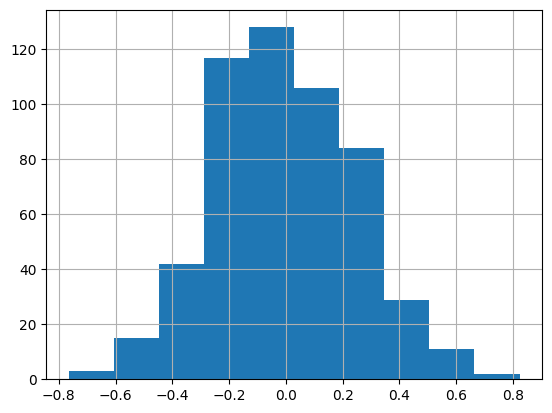

In [27]:
exposure_df['Increase in Exposure (Rank Change)'].hist()

In [28]:
exposure_df[
    [
        'O*NET-SOC Code', 
        'Title_x', 
        'nth Top AIOE (AIOE Rank)', 
        'nth Top C-AIOE (C-AIOE Rank)', 
        'Increase in Exposure (Rank Change)', 
        #'Increase in Exposure (Rank Change) Percent'
    ]
].sort_values(by='Increase in Exposure (Rank Change)')

,O*NET-SOC Code,Title_x,nth Top AIOE (AIOE Rank),nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change)
279,29-1217.00,Neurologists,0.901304,0.135940,-0.765363
163,23-1023.00,"Judges, Magistrate Judges, and Magistrates",0.998138,0.277467,-0.720670
0,11-1011.00,Chief Executives,0.921788,0.202980,-0.718808
20,11-9032.00,"Education Administrators, Kindergarten through...",0.823091,0.229050,-0.594041
157,21-2011.00,Clergy,0.949721,0.385475,-0.564246
...,...,...,...,...,...
224,27-1013.00,"Fine Artists, Including Painters, Sculptors, a...",0.208566,0.828678,0.620112
430,43-9071.00,"Office Machine Operators, Except Computer",0.227188,0.871508,0.644320
223,27-1012.00,Craft Artists,0.121043,0.769088,0.648045
497,51-6062.00,"Textile Cutting Machine Setters, Operators, an...",0.076350,0.813780,0.737430


In [29]:
exposure_df[(exposure_df['Increase in Exposure (Rank Change) Percent'] > -50 ) & (exposure_df['Increase in Exposure (Rank Change) Percent'] < 50)][[        'nth Top AIOE (AIOE Rank)', 
        'O*NET-SOC Code', 
        'Title_x', 
        'nth Top C-AIOE (C-AIOE Rank)', 
        'Increase in Exposure (Rank Change)', 
        'Increase in Exposure (Rank Change) Percent']]

,nth Top AIOE (AIOE Rank),O*NET-SOC Code,Title_x,nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change),Increase in Exposure (Rank Change) Percent
400,0.659218,43-4051.00,Customer Service Representatives,0.986965,0.327747,49.717514
228,0.270019,27-1023.00,Floral Designers,0.404097,0.134078,49.655172
387,0.614525,43-2011.00,"Switchboard Operators, Including Answering Ser...",0.912477,0.297952,48.484848
214,0.530726,25-4011.00,Archivists,0.787709,0.256983,48.421053
465,0.054004,49-3042.00,"Mobile Heavy Equipment Mechanics, Except Engines",0.080074,0.026071,48.275862
...,...,...,...,...,...,...
21,0.981378,11-9033.00,"Education Administrators, Postsecondary",0.515829,-0.465549,-47.438330
206,0.752328,25-2031.00,"Secondary School Teachers, Except Special and ...",0.394786,-0.357542,-47.524752
159,0.951583,23-1011.00,Lawyers,0.495345,-0.456238,-47.945205
469,0.147114,49-9021.00,"Heating, Air Conditioning, and Refrigeration M...",0.076350,-0.070764,-48.101266


In [30]:
# Add major group
major_groups = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military"
}
exposure_df['Major Group'] = exposure_df['O*NET-SOC Code'].str[:2].map(major_groups)

# When you say percentage, put it into a benchmark with the old v new. 

the historical for this conext is whatever was the rank before. It should provide the historical context or a context of the grouped iself.

for the visualization, perhaps show the move of Legal of AIOE to C-AIOE.

the next natural question for us to be academically robust is that what is the reality happening for the entire legal group. are those dimensions also true for the other legal professions because in every legal system, there would not be a lot of judges. 

For the ones that had high decrease in exposure (like legal and management), within those major groups, look at the differences between those groups. the natural question would be like to ask what would it be for paralegal or for like what are the other roles. Look at the other roles inside the group.

if we were to weight per job, then the paralegal, law clerks, and lawyers would be the most common job, so they should be weighted the most.

one way to possibly consider this 

to show this, we could show the original (AIOE rank) with an arrow and then you could have an arrow going up or down.

In [31]:
grouped_occupations_exposure = exposure_df.groupby('Major Group')[['nth Top AIOE (AIOE Rank)', 'nth Top C-AIOE (C-AIOE Rank)', 'Increase in Exposure (Rank Change)']].mean()
grouped_occupations_exposure.sort_values(by='Increase in Exposure (Rank Change)')

,nth Top AIOE (AIOE Rank),nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change)
Major Group,,,
Management,0.683031,0.426669,-0.256363
Healthcare Practitioners and Technical,0.455456,0.235903,-0.219553
Community and Social Service,0.713066,0.503880,-0.209187
Educational Instruction and Library,0.728319,0.524441,-0.203877
Legal,0.916733,0.744347,-0.172386
Protective Service,0.295469,0.188392,-0.107076
"Life, Physical, and Social Science",0.660786,0.573361,-0.087425
Business and Financial Operations,0.848231,0.818221,-0.030010
Architecture and Engineering,0.627621,0.602631,-0.024989


In [32]:
exposure_df[exposure_df['Major Group'] == 'Legal'][['O*NET-SOC Code', 'Title_x', 'nth Top AIOE (AIOE Rank)', 'nth Top C-AIOE (C-AIOE Rank)', 'Increase in Exposure (Rank Change)', 'Increase in Exposure (Rank Change) Percent']]

,O*NET-SOC Code,Title_x,nth Top AIOE (AIOE Rank),nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change),Increase in Exposure (Rank Change) Percent
164,23-2011.00,Paralegals and Legal Assistants,0.756052,0.880819,0.124767,16.502463
165,23-2093.00,"Title Examiners, Abstractors, and Searchers",0.845438,0.884544,0.039106,4.625551
160,23-1012.00,Judicial Law Clerks,0.940410,0.949721,0.009311,0.990099
162,23-1022.00,"Arbitrators, Mediators, and Conciliators",0.931099,0.862197,-0.068901,-7.400000
161,23-1021.00,"Administrative Law Judges, Adjudicators, and H...",0.994413,0.860335,-0.134078,-13.483146
159,23-1011.00,Lawyers,0.951583,0.495345,-0.456238,-47.945205
163,23-1023.00,"Judges, Magistrate Judges, and Magistrates",0.998138,0.277467,-0.720670,-72.201493


# c) Univariate & Bivariate Analysis of C-AIOE and Observed Exposure

C-AIOE is mostly bell-shaped while Observed Exposure has a very strong right skew where the median is just 0. In fact, 411 (54%) SOC codes have an Observed Exposure of 0. This would inform us later on that for both measures, it would be best to use the median as a possible threshold.

In [33]:
exposure_df[['C-AIOE', 'Observed Exposure']].describe()

,C-AIOE,Observed Exposure
count,537.000000,537.000000
mean,4.732421,0.103669
std,0.604165,0.146884
min,3.204920,0.000000
25%,4.318391,0.000000
50%,4.715776,0.034200
75%,5.160867,0.165100
max,6.270814,0.745100


It would be naturall right-skewed because of the bias it asks on the people who are already using Claude.

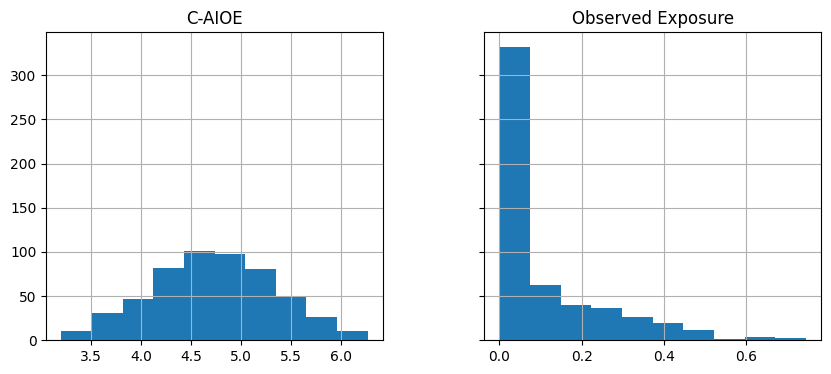

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
exposure_df[['C-AIOE', 'Observed Exposure']].hist(ax=axs)
plt.show()

For the bivariate relationship, the Pearson correlation between C-AIOE and Observed Exposure is 0.52, indicating a moderate positive linear association between the two measures. This relationship is notable because C-AIOE was constructed independently of Observed Exposure. For comparison, the Human Beta and Machine Beta measures, which are components used to construct Observed Exposure, have correlations of 0.59 and 0.64, respectively, with Observed Exposure. Thus, while C-AIOE has a weaker association with Observed Exposure than its constituent measures, its correlation of 0.52 still indicates a meaningful positive relationship between an independently constructed theoretical exposure measure and observed AI exposure.

In [35]:
exposure_df[['C-AIOE', 'dv_rating_beta', 'human_rating_beta', 'Observed Exposure']].corr()['Observed Exposure'].round(2)

C-AIOE               0.52
dv_rating_beta       0.61
human_rating_beta    0.54
Observed Exposure    1.00
Name: Observed Exposure, dtype: float64

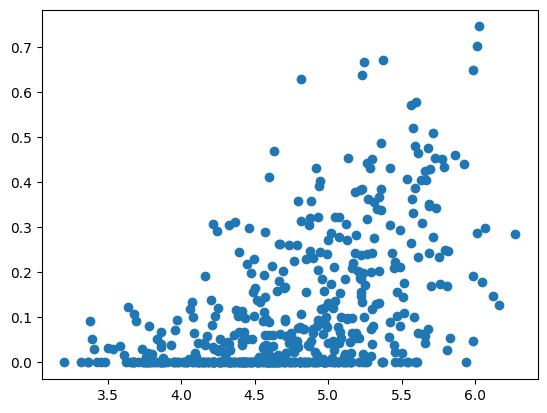

In [36]:
plt.scatter(exposure_df['C-AIOE'], exposure_df['Observed Exposure'])

# Step 2 - Identify different AI transition archetypes

## a) Identify the different AI transition archetypes based on the chosen Theoretical AI Exposure and Observed AI Exposure

The eventual objective is to determine which approach provides a more useful basis for identifying AI transition archetypes. In particular, we choose to have a percentile approach, where we transform $\text{C-AIOE}$ into a probability-scale measure so that it can be compared directly with Observed Exposure, which is already bounded between 0 and 1. We just did empirical percentile of $\text{C-AIOE}$ so that the transformed metric is also bounded between 0 and 1.


In [37]:
# get the percentile for the C-AIOE
exposure_df["C-AIOE Percentile"] = exposure_df["C-AIOE"].rank(pct=True)

In [38]:
def classify_transition_archetype(
    job: pd.Series,
    theoretical_column: str,
    observed_percentile_threshold: int = 50,
    exposure_df: pd.DataFrame = exposure_df,
) -> str:
    """Classify a job into an AI transition archetype.

    Classification is based on whether the job's theoretical AI
    exposure and observed AI exposure are below or above their
    respective medians across all occupations.

    Args:
        job: A pandas Series representing a single occupation.
        theoretical_column: Name of the theoretical AI exposure
            column used for classification.
        exposure_df: DataFrame containing AI exposure measures
            across occupations.

    Returns:
        The AI transition archetype assigned to the job.
    """
    # get the medians
    theoretical_median = exposure_df[theoretical_column].median()
    non_zero_df = exposure_df[exposure_df["Observed Exposure"] > 0]
    # observed_exposure_median = exposure_df["Observed Exposure"].median() # move this around so that w
    observed_percentile_threshold = observed_percentile_threshold / 100
    positive_observed_median = non_zero_df["Observed Exposure"].quantile(
        observed_percentile_threshold
    )
    #print(observed_exposure_median)

    # get the job's actual theoretical and observed job exposure
    theoretical_job = job[theoretical_column]
    observed_exposure_job = job["Observed Exposure"]

    # create the boolean
    theoretical_exposure_low = theoretical_job <= theoretical_median
    observed_exposure_low = observed_exposure_job <= positive_observed_median

    if theoretical_exposure_low:
        if observed_exposure_low:
            return "Limited Current Transformation" # low theoretical and observed
        return "AI-Enabled Expansion" # low theoretical but high observed

    if observed_exposure_low:
        return "Latent Transformation" # high theoretical but low observed

    return "Active Transformation" # high theoretical and observed

## b) Determining if there exists reasonably stable AI transition archetypes

To determine whether reasonably stable AI transition archetypes exist, we use Cohen's Kappa ($\kappa$) to measure the agreement between the classifications produced by different theoretical exposure measures. Cohen's Kappa measures agreement between two categorical classifications while accounting for the agreement that would be expected by chance. The statistic ranges from $-1$ to $1$, where $1$ represents perfect agreement and $0$ represents agreement equivalent to chance. Under the commonly used interpretation of Landis and Koch (1977), values between $0.41$ and $0.60$ represent moderate agreement.

We therefore define an AI transition archetype classification as reasonably stable when the Cohen's Kappa between the archetypes derived from C-AIOE and those derived from the selected benchmark theoretical exposure measure is greater than $0.41$, corresponding to at least moderate agreement under this interpretation.

For the benchmark comparison, we use the Human and LLM Beta measure developed in Labor market impacts of AI: A new measure and early evidence by Massenkoff and McCrory [(2026)](https://www.anthropic.com/research/labor-market-impacts). This measure is selected because it was used as a theoretical exposure measure in the study's comparison of theoretical AI exposure with observed AI exposure. The Human and LLM Beta measure therefore provides a relevant benchmark for evaluating whether the transition archetypes identified using C-AIOE are consistent with Anthropic's (i.e., [Elondou's](https://arxiv.org/abs/2303.10130)) theoretical exposure framework.

In [39]:
theoretical_exposure_measurments = [
    "AIOE",
    #"C-AIOE",
    "C-AIOE Percentile",
    #"Observed Exposure",
    #"dv_rating_alpha",
    "dv_rating_beta",
    #"dv_rating_gamma",
    #"human_rating_alpha",
    "human_rating_beta",
    #"human_rating_gamma",
]


# apply and classify each job into a transition archetype
archetype_columns = [
    f"Archetype {measurement}"
    for measurement in theoretical_exposure_measurments
]
for theoretical_exposure_measurment in theoretical_exposure_measurments:
    col_name = "Archetype " + theoretical_exposure_measurment
    exposure_df[col_name] = exposure_df.apply(
        classify_transition_archetype,
        theoretical_column=theoretical_exposure_measurment,
        axis=1
    )

In [40]:
kappas = {'Archetype 1':[], 'Archetype 2': [], "Cohen's Kappa": []}
for measurement1, measurement2 in combinations(archetype_columns, 2):
    kappa = cohen_kappa_score(
        exposure_df[measurement1], exposure_df[measurement2]
    )
    kappas['Archetype 1'].append(measurement1)
    kappas['Archetype 2'].append(measurement2)
    kappas["Cohen's Kappa"].append(kappa)

kappas_df = pd.DataFrame(kappas)
kappas_df.sort_values(by="Cohen's Kappa")

,Archetype 1,Archetype 2,Cohen's Kappa
4,Archetype C-AIOE Percentile,Archetype human_rating_beta,0.609329
3,Archetype C-AIOE Percentile,Archetype dv_rating_beta,0.631651
0,Archetype AIOE,Archetype C-AIOE Percentile,0.643886
1,Archetype AIOE,Archetype dv_rating_beta,0.768569
2,Archetype AIOE,Archetype human_rating_beta,0.774214
5,Archetype dv_rating_beta,Archetype human_rating_beta,0.796017


## c) Determining what is the best percentile threshold

We are going to adjust the percentile threshold for observed exposure in order to recalibrate the AI transition archetypes.

The main idea is to separate occupations into two groups based on observed exposure:

* Zero Observed Usage: occupations with observed exposure = 0 are automatically classified as Low Usage. Since there is no observed AI exposure, these occupations should clearly fall under low observed usage.
* Positive Observed Usage: occupations with observed exposure > 0 are compared against a percentile threshold based on the positive observed-exposure distribution.

  * At or below the threshold -> Low Usage
  * Above the threshold -> High Usage

Since observed exposure is highly right-skewed, we want to determine which percentile threshold gives us a reasonable recalibration of the archetypes. We will therefore test different percentile thresholds and examine how the number of occupations in each transformation category changes.

Interestingly, the 50th percentile appears to give a reasonable result. At this threshold, we get 224 occupations in Latent Transformation and 165 occupations in Active Transformation. This seems sufficiently aligned with the expectation that latent transformation should contain a larger group, while active transformation should contain a smaller but still meaningful group.

Therefore, 50% is currently a strong candidate for the observed-exposure threshold, although we will still examine the resulting distributions before finalizing it.

Once the observed-exposure treatment and threshold are decided, we can proceed with the stage-three automation and augmentation analysis.


In [41]:
# now do it where we change around the percentile threshold for the observed exposure greater than 0
thresholds = range(50, 76)
for observed_percentile_threshold in thresholds:
    col_name = "Archetype C-AIOE " + str(observed_percentile_threshold)
    exposure_df[col_name] = exposure_df.apply(
        classify_transition_archetype,
        theoretical_column=theoretical_exposure_measurment,
        observed_percentile_threshold=observed_percentile_threshold,
        axis=1
    )

archetype_numbered_columns = [
    f"Archetype C-AIOE {observed_percentile_threshold}"
    for observed_percentile_threshold in thresholds
]

kappas = {'Archetype 1':[], 'Archetype 2': [], "Cohen's Kappa": []}
for measurement1, measurement2 in combinations(archetype_numbered_columns, 2):
    kappa = cohen_kappa_score(
        exposure_df[measurement1], exposure_df[measurement2]
    )
    kappas['Archetype 1'].append(measurement1)
    kappas['Archetype 2'].append(measurement2)
    kappas["Cohen's Kappa"].append(kappa)

kappas_df = pd.DataFrame(kappas)
kappas_df

,Archetype 1,Archetype 2,Cohen's Kappa
0,Archetype C-AIOE 50,Archetype C-AIOE 51,0.991491
1,Archetype C-AIOE 50,Archetype C-AIOE 52,0.982985
2,Archetype C-AIOE 50,Archetype C-AIOE 53,0.974417
3,Archetype C-AIOE 50,Archetype C-AIOE 54,0.965894
4,Archetype C-AIOE 50,Archetype C-AIOE 55,0.957320
...,...,...,...
320,Archetype C-AIOE 72,Archetype C-AIOE 74,0.981901
321,Archetype C-AIOE 72,Archetype C-AIOE 75,0.969762
322,Archetype C-AIOE 73,Archetype C-AIOE 74,0.990932
323,Archetype C-AIOE 73,Archetype C-AIOE 75,0.978789


In [42]:
exposure_df[archetype_numbered_columns].apply(pd.Series.value_counts, normalize=True)

,Archetype C-AIOE 50,Archetype C-AIOE 51,Archetype C-AIOE 52,Archetype C-AIOE 53,Archetype C-AIOE 54,Archetype C-AIOE 55,Archetype C-AIOE 56,Archetype C-AIOE 57,Archetype C-AIOE 58,Archetype C-AIOE 59,...,Archetype C-AIOE 66,Archetype C-AIOE 67,Archetype C-AIOE 68,Archetype C-AIOE 69,Archetype C-AIOE 70,Archetype C-AIOE 71,Archetype C-AIOE 72,Archetype C-AIOE 73,Archetype C-AIOE 74,Archetype C-AIOE 75
AI-Enabled Expansion,0.035382,0.033520,0.033520,0.029795,0.029795,0.027933,0.027933,0.026071,0.024209,0.024209,...,0.020484,0.020484,0.020484,0.018622,0.018622,0.016760,0.014898,0.014898,0.014898,0.014898
Active Transformation,0.258845,0.255121,0.249534,0.247672,0.242086,0.238361,0.232775,0.225326,0.223464,0.217877,...,0.180633,0.175047,0.169460,0.163873,0.158287,0.154562,0.150838,0.145251,0.139665,0.132216
Latent Transformation,0.240223,0.243948,0.249534,0.251397,0.256983,0.260708,0.266294,0.273743,0.275605,0.281192,...,0.318436,0.324022,0.329609,0.335196,0.340782,0.344507,0.348231,0.353818,0.359404,0.366853
Limited Current Transformation,0.465549,0.467412,0.467412,0.471136,0.471136,0.472998,0.472998,0.474860,0.476723,0.476723,...,0.480447,0.480447,0.480447,0.482309,0.482309,0.484171,0.486034,0.486034,0.486034,0.486034


In [43]:
exposure_df[archetype_numbered_columns].apply(pd.Series.value_counts)

,Archetype C-AIOE 50,Archetype C-AIOE 51,Archetype C-AIOE 52,Archetype C-AIOE 53,Archetype C-AIOE 54,Archetype C-AIOE 55,Archetype C-AIOE 56,Archetype C-AIOE 57,Archetype C-AIOE 58,Archetype C-AIOE 59,...,Archetype C-AIOE 66,Archetype C-AIOE 67,Archetype C-AIOE 68,Archetype C-AIOE 69,Archetype C-AIOE 70,Archetype C-AIOE 71,Archetype C-AIOE 72,Archetype C-AIOE 73,Archetype C-AIOE 74,Archetype C-AIOE 75
AI-Enabled Expansion,19,18,18,16,16,15,15,14,13,13,...,11,11,11,10,10,9,8,8,8,8
Active Transformation,139,137,134,133,130,128,125,121,120,117,...,97,94,91,88,85,83,81,78,75,71
Latent Transformation,129,131,134,135,138,140,143,147,148,151,...,171,174,177,180,183,185,187,190,193,197
Limited Current Transformation,250,251,251,253,253,254,254,255,256,256,...,258,258,258,259,259,260,261,261,261,261


In [97]:
# Time to actually export this
final_exposure_df = exposure_df.rename(
    columns={
        "Title_x": "Title",
        "dv_rating_beta": "LLM Rating Beta",
        "human_rating_beta": "Human Rating Beta",
        "Archetype C-AIOE 50": "Archetype C-AIOE",
    }
)

columns_to_keep = [
    "O*NET-SOC Code",
    "Title",
    "Major Group",
    "AIOE",
    "Complementarity",
    "C-AIOE",
    "Observed Exposure",
    "LLM Rating Beta",
    "Human Rating Beta",
    "Archetype C-AIOE",
    "Augmentation Percent",
    "Automation Percent",
    "Directive Percent",
    "Feedback Loop Percent",
    "Learning Percent",
    "Task Iteration Percent",
    "Validation Percent",
    "None Percent",
]

final_exposure_df = final_exposure_df[columns_to_keep]

## d) What are the archetypes composed of?

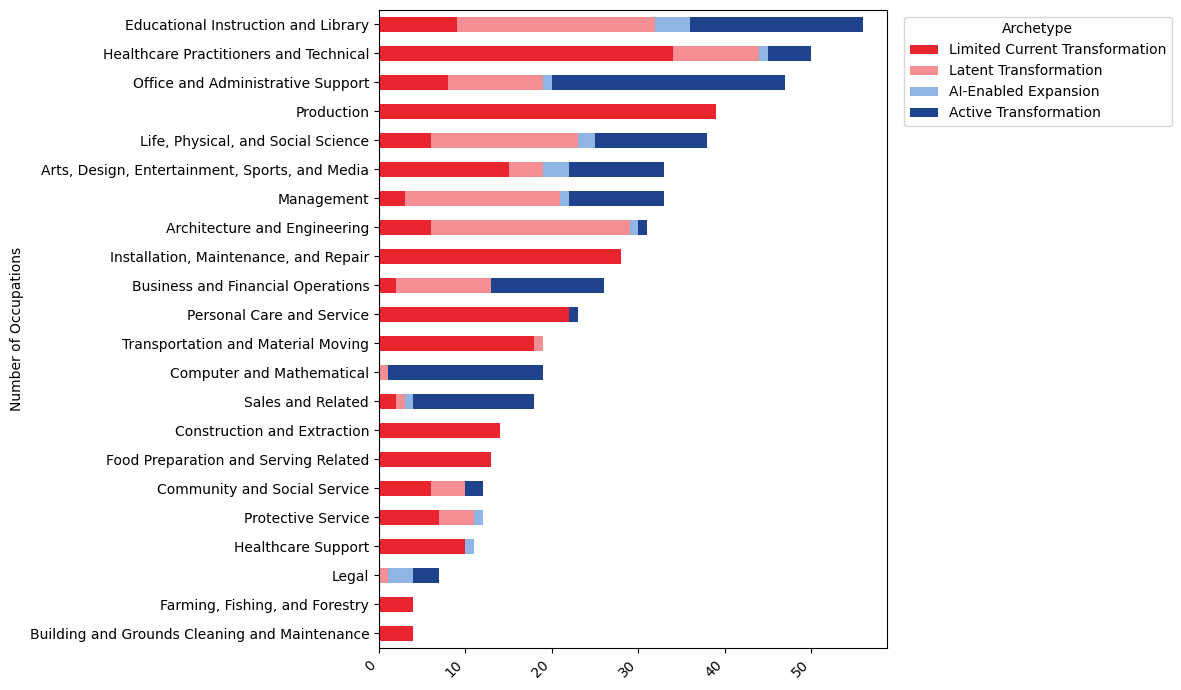

In [119]:
archetype_counts = pd.crosstab(
    final_exposure_df["Major Group"],
    final_exposure_df["Archetype C-AIOE"],
)

archetype_order = [
    "Limited Current Transformation",
    "Latent Transformation",
    "AI-Enabled Expansion",
    "Active Transformation",
]

archetype_counts = archetype_counts.reindex(
    columns=archetype_order,
    fill_value=0,
)

archetype_counts = archetype_counts.loc[
    archetype_counts.sum(axis=1).sort_values(ascending=False).index
]

archetype_colors = [
    "#e9252f",
    "#f58f94",
    "#8eb5e3",
    "#1e438c",
]

ax = archetype_counts[::-1].plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=archetype_colors,
)

#ax.set_xlabel("")
ax.set_ylabel("Number of Occupations")
#ax.set_title("AI Transition Archetypes by Major Group")

ax.legend(
    title="Archetype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Step 3 - Understand whether AI use is automation or augmentation

## a) Exploratory Data Analysis of the relationship between Archetypes to Automation/Augmentation Share

In [98]:
complementarity_measures = [
    "Augmentation Percent",
    "Automation Percent",
    "Directive Percent",
    "Feedback Loop Percent",
    "Learning Percent",
    "Task Iteration Percent",
    "Validation Percent",
    "None Percent",
]

final_exposure_df.groupby('Archetype C-AIOE')[complementarity_measures].agg(['mean', 'median'])

Augmentation Percent        Automation Percent  \
                                               mean median               mean   
Archetype C-AIOE                                                                
AI-Enabled Expansion                      50.472105  55.27          49.527895   
Active Transformation                     50.930647  52.36          49.069353   
Latent Transformation                     55.624806  57.63          44.375194   
Limited Current Transformation            42.131760  44.59          57.868520   

                                      Directive Percent          \
                               median              mean  median   
Archetype C-AIOE                                                  
AI-Enabled Expansion            44.73         38.381053  38.240   
Active Transformation           47.64         33.338921  30.250   
Latent Transformation           42.37         31.577984  29.380   
Limited Current Transformation  55.41         37.873720  35.275   

                               Feedback Loop Percent        Learning Percent  \
                                                mean median             mean   
Archetype C-AIOE                                                               
AI-Enabled Expansion                       10.560000   6.89        16.337895   
Active Transformation                      14.490719   9.62        15.054964   
Latent Transformation                      12.012481  10.58        22.112016   
Limited Current Transformation             16.901680  12.86        14.443400   

                                      Task Iteration Percent         \
                               median                   mean median   
Archetype C-AIOE                                                      
AI-Enabled Expansion            14.00              30.972105  33.33   
Active Transformation           10.26              31.476115  29.17   
Latent Transformation           17.24              28.017519  26.37   
Limited Current Transformation   8.99              22.523080  19.64   

                               Validation Percent        None Percent         
                                             mean median         mean median  
Archetype C-AIOE                                                              
AI-Enabled Expansion                     2.570000  2.390     1.178947  0.970  
Active Transformation                    3.290072  2.440     2.349712  1.100  
Latent Transformation                    4.614961  3.200     1.664186  1.110  
Limited Current Transformation           3.162640  2.025     5.095440  1.445

The first test is just to see if there is indeed a difference between the different archetypes for each AI measurement. The answer is yeah...

In [99]:
from scipy.stats import kruskal, ttest_ind

# sorry the code for these ones are ChatGPT generated
# idk how to do statistical tests actually...
for measure in complementarity_measures:
    groups = [
        group[measure].dropna()
        for _, group in final_exposure_df.groupby("Archetype C-AIOE")
    ]

    statistic, p_value = kruskal(*groups)

    print(f"{measure}: H={statistic:.3f}, p={p_value:.4f}")

Augmentation Percent: H=51.905, p=0.0000
Automation Percent: H=51.905, p=0.0000
Directive Percent: H=14.163, p=0.0027
Feedback Loop Percent: H=22.683, p=0.0000
Learning Percent: H=24.668, p=0.0000
Task Iteration Percent: H=39.580, p=0.0000
Validation Percent: H=15.623, p=0.0014
None Percent: H=4.811, p=0.1862


Note that we never do any comparison between one archetype to AI-Enabled Expansion. There are only 19 jobs that are labeled as AI-Enabled Expansion.

The more interesting question for me is to ask if there is a differnece between Latent Transformation and Limited Current Transformation. Both have Low Observed Exposure. However, Latent Transformation has high theoretical exposure while Limited Current Transformation has low theoretical exposure. What is most interesting is that occupations from Latent Transformation have a much higher Augmentation percentage of 57.63% compared to Limited Current Transformation's Augmentation percentage of 44.59%. To check if this was a statistically significant, I did a t-test, and it was!

In [100]:
# this should be a t-testt
group_a = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Latent Transformation"
]

group_b = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Limited Current Transformation"
]

for measure in complementarity_measures:
    statistic, p_value = ttest_ind(
        group_a[measure].dropna(),
        group_b[measure].dropna(),
        equal_var=False,
    )

    print(f"{measure}: t={statistic:.3f}, p={p_value:.4f}")

Augmentation Percent: t=7.884, p=0.0000
Automation Percent: t=-7.884, p=0.0000
Directive Percent: t=-3.965, p=0.0001
Feedback Loop Percent: t=-4.290, p=0.0000
Learning Percent: t=4.252, p=0.0000
Task Iteration Percent: t=3.438, p=0.0007
Validation Percent: t=2.605, p=0.0098
None Percent: t=-4.909, p=0.0000


In [101]:
# this should be a t-testt
group_a = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Latent Transformation"
]

group_b = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Active Transformation"
]

for measure in complementarity_measures:
    statistic, p_value = ttest_ind(
        group_a[measure].dropna(),
        group_b[measure].dropna(),
        equal_var=False,
    )

    print(f"{measure}: t={statistic:.3f}, p={p_value:.4f}")

Augmentation Percent: t=2.660, p=0.0083
Automation Percent: t=-2.660, p=0.0083
Directive Percent: t=-1.173, p=0.2417
Feedback Loop Percent: t=-1.804, p=0.0725
Learning Percent: t=3.752, p=0.0002
Task Iteration Percent: t=-2.000, p=0.0465
Validation Percent: t=2.372, p=0.0185
None Percent: t=-1.546, p=0.1237


## b) Define if a job is AI-Powered or Transition Pressure based if it has higher or lower Augmentation Percent than 50%

In [120]:
# create the actual sub archetypes
final_exposure_df['Sub-Archetype'] = (
    final_exposure_df['Augmentation Percent']
    .apply(
        lambda share : 
        'AI-Powered' if share > 50 else 'Transition Pressure'
    )
)

In [121]:
# look only into those of active transformation
is_active_transformation = final_exposure_df['Archetype C-AIOE'] == 'Active Transformation'
active_transformation_df = final_exposure_df[is_active_transformation]

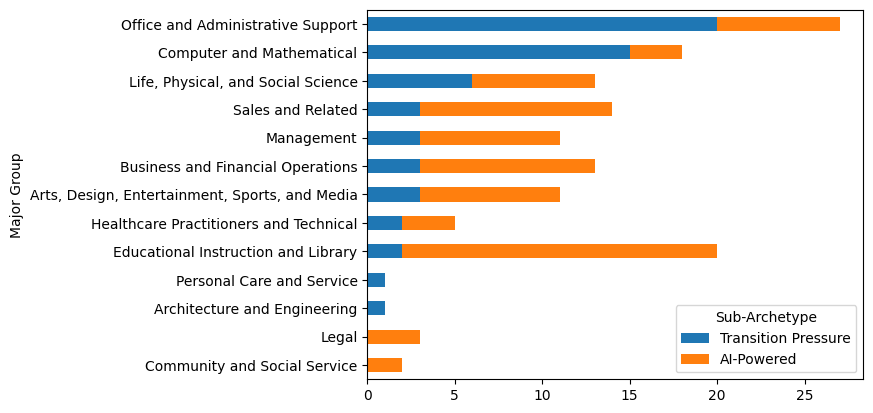

In [135]:
sub_archetype_df = pd.crosstab(active_transformation_df['Major Group'], active_transformation_df['Sub-Archetype'])
sub_archetype_df = sub_archetype_df.reindex(
    columns=['Transition Pressure', 'AI-Powered'],
    fill_value=0,
)
# sort values by largest to smallest
# sub_archetype_df = sub_archetype_df.loc[
#     sub_archetype_df.sum(axis=1).sort_values(ascending=False).index
# ][::-1]
sub_archetype_df.sort_values(by='Transition Pressure', inplace=True)
sub_archetype_df.plot(kind='barh', stacked=True);